Import Libraries

In [100]:
import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix ,classification_report

Lood data

In [101]:
# Download latest version
path = kagglehub.dataset_download("atharvaingle/crop-recommendation-dataset")
print(os.listdir(path))

Using Colab cache for faster access to the 'crop-recommendation-dataset' dataset.
['Crop_recommendation.csv']


In [102]:
CSV_PATH = os.path.join(path, "Crop_recommendation.csv")

Explore Dataset

In [103]:
df = pd.read_csv(CSV_PATH)
df

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


In [104]:
df.shape

(2200, 8)

In [105]:
df.columns.tolist()

['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']

In [106]:
df.isnull().sum()

,0
N,0
P,0
K,0
temperature,0
humidity,0
ph,0
rainfall,0
label,0


In [107]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


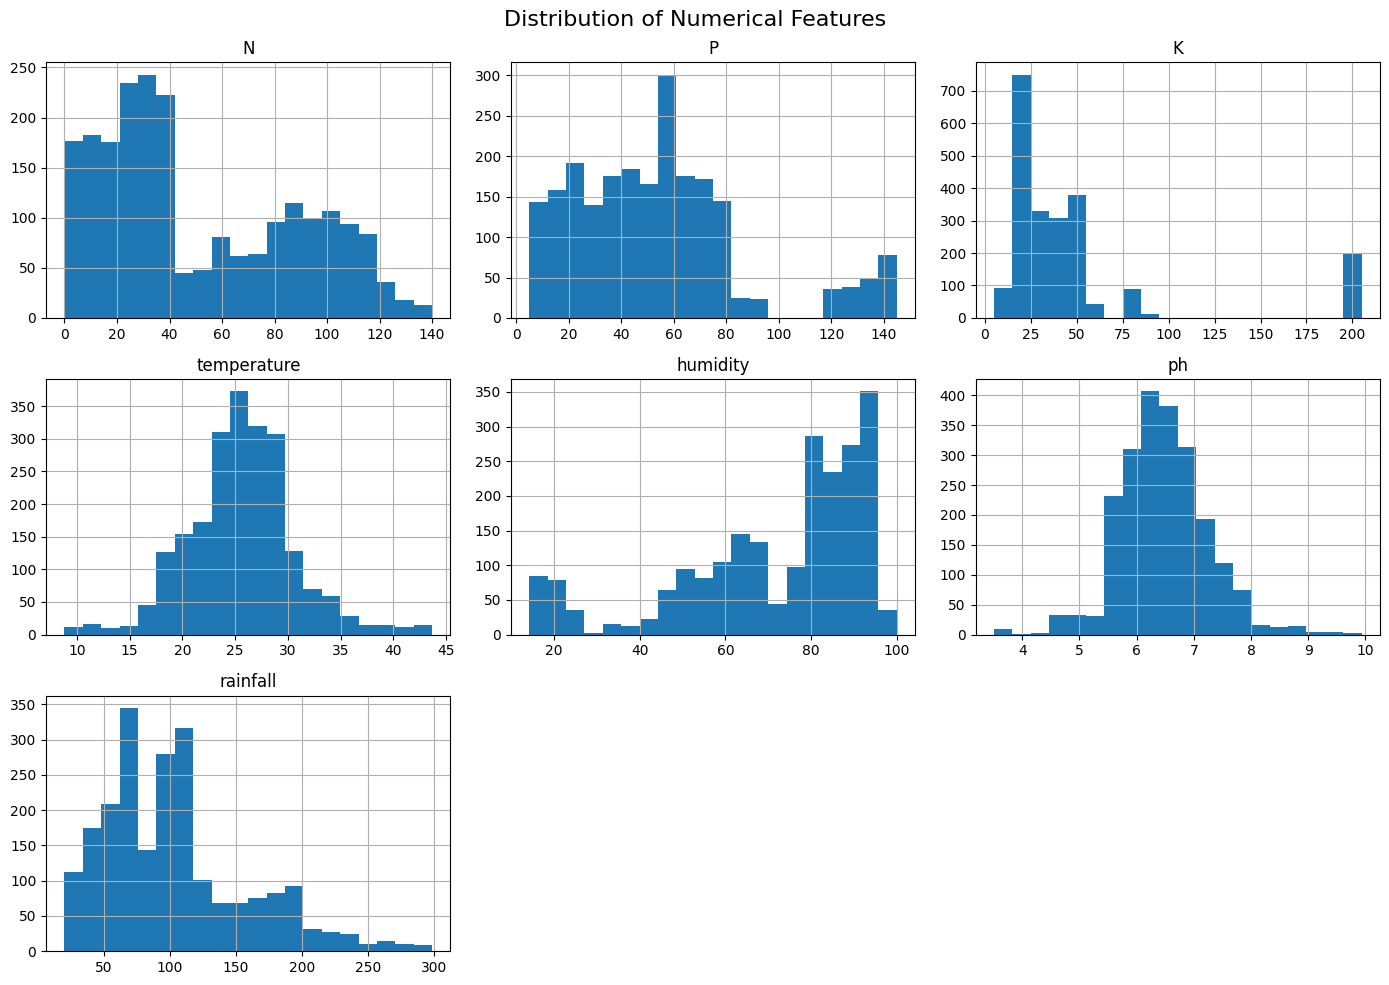

In [108]:
df.drop(columns=["label"]).hist(figsize=(14, 10),bins=20)

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

In [109]:
features = df.drop(columns=["label"])

In [110]:
Q1 = features.quantile(0.25)
Q3 = features.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_count = (
    ((features < lower_bound) | (features > upper_bound)).sum()
)

print("Number of outliers in each feature:")
print(outliers_count)

print("\nUpper bounds:")
print(upper_bound)

print("\nLower bounds:")
print(lower_bound)

Number of outliers in each feature:
N                0
P              138
K              200
temperature     86
humidity        30
ph              57
rainfall       100
dtype: int64

Upper bounds:
N              179.125000
P              128.000000
K               92.500000
temperature     37.250073
humidity       134.478998
ph               8.351567
rainfall       213.841241
dtype: float64

Lower bounds:
N             -73.875000
P             -32.000000
K             -23.500000
temperature    14.080956
humidity       15.731726
ph              4.543768
rainfall      -25.022047
dtype: float64


In [111]:
crop_means = df.groupby("label").mean(numeric_only=True)
crop_means = crop_means.sort_index()

In [112]:
display(crop_means)

,N,P,K,temperature,humidity,ph,rainfall
label,,,,,,,
apple,20.80,134.22,199.89,22.630942,92.333383,5.929663,112.654779
banana,100.23,82.01,50.05,27.376798,80.358123,5.983893,104.626980
blackgram,40.02,67.47,19.24,29.973340,65.118426,7.133952,67.884151
chickpea,40.09,67.79,79.92,18.872847,16.860439,7.336957,80.058977
coconut,21.98,16.93,30.59,27.409892,94.844272,5.976562,175.686646
coffee,101.20,28.74,29.94,25.540477,58.869846,6.790308,158.066295
cotton,117.77,46.24,19.56,23.988958,79.843474,6.912675,80.398043
grapes,23.18,132.53,200.11,23.849575,81.875228,6.025937,69.611829
jute,78.40,46.86,39.99,24.958376,79.639864,6.732778,174.792798


Encode Target Labels

In [113]:
X = df[["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]]
y = df["label"]


In [114]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(label_encoder.classes_)

['apple' 'banana' 'blackgram' 'chickpea' 'coconut' 'coffee' 'cotton'
 'grapes' 'jute' 'kidneybeans' 'lentil' 'maize' 'mango' 'mothbeans'
 'mungbean' 'muskmelon' 'orange' 'papaya' 'pigeonpeas' 'pomegranate'
 'rice' 'watermelon']


In [115]:
print("\nOriginal labels:")
print(y.head(10).tolist())

print("\nEncoded labels:")
print(y_encoded[:10])


Original labels:
['rice', 'rice', 'rice', 'rice', 'rice', 'rice', 'rice', 'rice', 'rice', 'rice']

Encoded labels:
[20 20 20 20 20 20 20 20 20 20]


Split Data

In [116]:
X_train, X_temp, y_train, y_temp = train_test_split(X,y_encoded,test_size=0.30,random_state=42,stratify=y_encoded)

X_val, X_test, y_val, y_test = train_test_split(X_temp,y_temp,test_size=0.50,random_state=42,stratify=y_temp)


Feature Scaling

In [117]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [118]:
num_classes = len(label_encoder.classes_)

mlp_model = keras.Sequential([

    layers.Input(shape=(7,)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.20),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.20),
    layers.Dense(num_classes, activation="softmax")
])
mlp_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 128)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 22)             │         1,430 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,710 (41.84 KB)

 Trainable params: 10,710 (41.84 KB)

 Non-trainable params: 0 (0.00 B)

In [119]:
mlp_model.compile(

    loss="sparse_categorical_crossentropy",
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),  metrics=["accuracy"]
)


In [120]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

model_checkpoint = keras.callbacks.ModelCheckpoint(
    "best_crop_mlp.keras",
    monitor="val_loss",
    save_best_only=True
)


In [121]:
history = mlp_model.fit(
    X_train_scaled,
    y_train,

    validation_data=(
        X_val_scaled,
        y_val
    ),

    epochs=50,
    batch_size=32,

    callbacks=[
        early_stopping,
        model_checkpoint
    ],

    verbose=1
)


Epoch 1/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.2792 - loss: 2.7567 - val_accuracy: 0.6182 - val_loss: 2.2285
Epoch 2/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5584 - loss: 1.8365 - val_accuracy: 0.8152 - val_loss: 1.2630
Epoch 3/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7169 - loss: 1.0811 - val_accuracy: 0.8727 - val_loss: 0.7001
Epoch 4/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7727 - loss: 0.7481 - val_accuracy: 0.8758 - val_loss: 0.4838
Epoch 5/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8234 - loss: 0.5783 - val_accuracy: 0.9030 - val_loss: 0.3716
Epoch 6/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8455 - loss: 0.4963 - val_accuracy: 0.9455 - val_loss: 0.2986
Epoch 7/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8714 - loss: 0.4072 - val_accuracy: 0.9424 - val_loss: 0.2532
Epoch 8/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8818 - loss: 0.3665 - val_accuracy: 0.9485 - val_loss

In [122]:
test_loss, test_accuracy = mlp_model.evaluate(X_test_scaled, y_test)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9879 - loss: 0.0458 


In [123]:
train_accuracy = mlp_model.evaluate(X_train_scaled, y_train)
test_accuracy = mlp_model.evaluate(X_test_scaled, y_test)

print("Train Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9857 - loss: 0.0431
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9879 - loss: 0.0458 
Train Accuracy: [0.04314726963639259, 0.9857142567634583]
Test Accuracy: [0.045776721090078354, 0.9878787994384766]


In [124]:
y_pred_prob = mlp_model.predict(X_test_scaled,verbose=0)

y_pred = np.argmax(y_pred_prob, axis=1)

report = classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
)

print(report)

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        15
      banana       1.00      1.00      1.00        15
   blackgram       1.00      1.00      1.00        15
    chickpea       1.00      1.00      1.00        15
     coconut       1.00      1.00      1.00        15
      coffee       1.00      1.00      1.00        15
      cotton       0.94      1.00      0.97        15
      grapes       1.00      1.00      1.00        15
        jute       0.93      0.87      0.90        15
 kidneybeans       1.00      1.00      1.00        15
      lentil       1.00      1.00      1.00        15
       maize       1.00      0.93      0.97        15
       mango       1.00      1.00      1.00        15
   mothbeans       1.00      1.00      1.00        15
    mungbean       1.00      1.00      1.00        15
   muskmelon       1.00      1.00      1.00        15
      orange       1.00      1.00      1.00        15
      papaya       1.00    

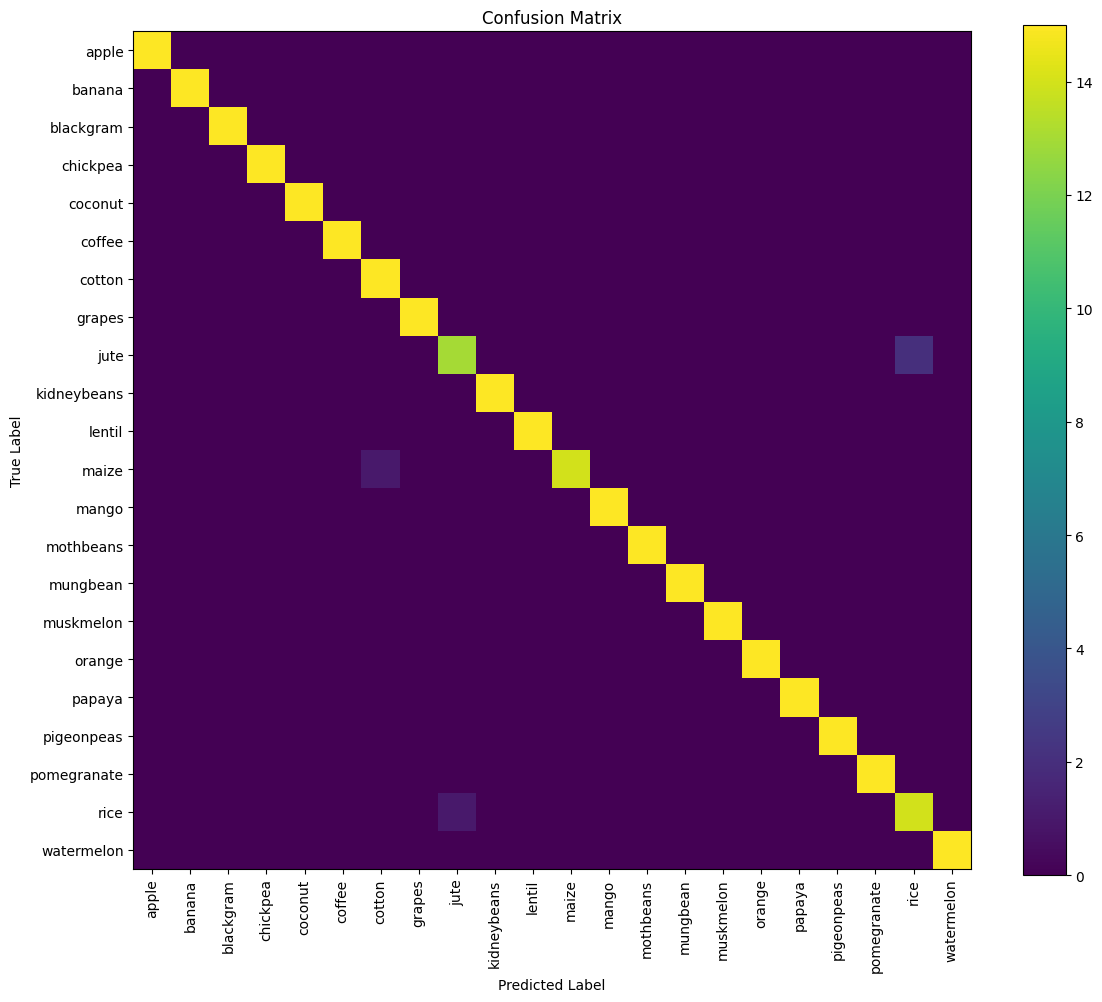

In [125]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 10))
plt.imshow(cm)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_,
    rotation=90
)

plt.yticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_
)

plt.title("Confusion Matrix")
plt.colorbar()
plt.tight_layout()
plt.show()

In [126]:
mlp_model.save("best_crop_mlp.keras")